# Radiative coupling: α and β

Quantify how 3D vs 1D RT modulates the surface buoyancy flux beneath
cloud roots, following the Stevens (2007) framework.

| Symbol | Definition |
|--------|------------|
| $\tilde Q_{\rho,0}$ | Equivalent surface buoyancy flux $= w'\theta_l' + \epsilon_v \Theta\, w'q_t'$ |
| $\alpha$ | $\tilde Q_{\rho,0}^{\rm cr} / \langle \tilde Q_{\rho,0} \rangle$ — radiative coupling parameter |
| $\beta$ | $\delta \tilde Q_{\rho,0}^{\rm cr} / \delta R_n^{\rm cr}$ — partitioning coefficient |

See `analysis_subtask.md` for full derivation.

In [1]:
import sys
import pickle as _pkl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd() / 'cloud_roots'))

from cass_analysis import (
    eps_v, LST_OFFSET, rho, cp,
    sim_time_to_lst, lst_window_mask,
    load_sfc_xy, load_sfc_sw_dn, load_stats, load_3d_nc,
    cloud_mask_2d, compute_z_sl, cloud_top_za,
    RT_LABEL, RT_STYLE,
)
from catalog import make_runset, CASS_ROOT
from sw_surface_composite import zenith_angle
from scipy.stats import pearsonr

In [2]:
# ── Config ─────────────────────────────────────────────────────────────────────
EXPT_KEY  = 'no_aerosols_zero_wind'
rs        = make_runset(EXPT_KEY)
N_REPS    = 4
THETA_REF = 300.0   # K — reference potential temperature for Q̃_ρ
LWP_THRESH = 1e-3   # kg m⁻² — cloud-root column threshold
SAVE_PDF  = False

CASES = [
    dict(key='1D', rt='2stream'),
    dict(key='3D', rt='raytracer'),
]

In [3]:
# ── Per-timestep conditional means ────────────────────────────────────────────
# For each rep & RT: compute domain-mean and cloud-root-mean of Q̃_ρ, SW↓, R_n
# at every xy output timestep.

def compute_timeseries(run_dir):
    """Return dict of per-timestep scalars for one rep."""
    run_dir = Path(run_dir)

    thl_fb, t_sec = load_sfc_xy(run_dir, 'thl_fluxbot')
    qt_fb, _      = load_sfc_xy(run_dir, 'qt_fluxbot')
    lwp, _        = load_sfc_xy(run_dir, 'qlqi_path')
    sw_dn, _      = load_sfc_sw_dn(run_dir)
    lw_dn, _      = load_sfc_xy(run_dir, 'lw_flux_dn')
    lw_up, _      = load_sfc_xy(run_dir, 'lw_flux_up')
    ct, _         = load_sfc_xy(run_dir, 'qlqi_top')
    cb, _         = load_sfc_xy(run_dir, 'qlqi_base')

    lw_net = lw_dn - lw_up   # negative (surface emits more than it receives)

    lst = sim_time_to_lst(t_sec)
    nt  = len(t_sec)

    # Equivalent buoyancy flux: Q̃_ρ = thl_fluxbot + ε_v · Θ · qt_fluxbot
    Q_rho = thl_fb + eps_v * THETA_REF * qt_fb   # (nt, ny, nx)

    # Per-timestep stats
    out = dict(
        t_sec=t_sec, lst=lst,
        # Domain means
        Q_rho_dm   = np.empty(nt),
        sw_dn_dm   = np.empty(nt),
        lw_net_dm  = np.empty(nt),
        thl_fb_dm  = np.empty(nt),
        qt_fb_dm   = np.empty(nt),
        # Cloud-root conditional means
        Q_rho_cr   = np.full(nt, np.nan),
        sw_dn_cr   = np.full(nt, np.nan),
        lw_net_cr  = np.full(nt, np.nan),
        thl_fb_cr  = np.full(nt, np.nan),
        qt_fb_cr   = np.full(nt, np.nan),
        n_cloud    = np.zeros(nt, dtype=int),
        n_total    = np.zeros(nt, dtype=int),
        lwp_dm     = np.empty(nt),
        lwp_cr     = np.full(nt, np.nan),
        depth_cr   = np.full(nt, np.nan),
    )

    for ti in range(nt):
        cm = lwp[ti] > LWP_THRESH
        nc = int(cm.sum())
        ntot = cm.size
        out['n_cloud'][ti] = nc
        out['n_total'][ti] = ntot

        out['Q_rho_dm'][ti]  = np.nanmean(Q_rho[ti])
        out['sw_dn_dm'][ti]  = np.nanmean(sw_dn[ti])
        out['lw_net_dm'][ti] = np.nanmean(lw_net[ti])
        out['thl_fb_dm'][ti] = np.nanmean(thl_fb[ti])
        out['qt_fb_dm'][ti]  = np.nanmean(qt_fb[ti])
        out['lwp_dm'][ti]    = np.nanmean(lwp[ti]) * 1e3   # g m⁻²

        if nc > 0:
            out['Q_rho_cr'][ti]  = np.nanmean(Q_rho[ti][cm])
            out['sw_dn_cr'][ti]  = np.nanmean(sw_dn[ti][cm])
            out['lw_net_cr'][ti] = np.nanmean(lw_net[ti][cm])
            out['thl_fb_cr'][ti] = np.nanmean(thl_fb[ti][cm])
            out['qt_fb_cr'][ti]  = np.nanmean(qt_fb[ti][cm])
            out['lwp_cr'][ti]    = np.nanmean(lwp[ti][cm]) * 1e3   # g m⁻²
            depth = ct[ti][cm] - cb[ti][cm]
            out['depth_cr'][ti]  = np.nanmean(depth[depth > 0]) if (depth > 0).any() else np.nan

    return out


# ── Load all reps ────────────────────────────────────────────────────────────
_cache = CASS_ROOT / 'analysis' / 'radcoupling_cache.pkl'

if _cache.exists():
    with open(_cache, 'rb') as f:
        ts_data = _pkl.load(f)
    print(f'Loaded from {_cache}')
else:
    ts_data = {}  # ts_data[case_key] = list of per-rep dicts
    for case in CASES:
        print(f"\n{RT_LABEL[case['rt']]}:")
        reps = []
        for rd in rs.dirs[case['rt']]:
            if not rd.exists():
                print(f'  SKIP {rd.name}')
                continue
            print(f'  {rd.name} ...', end=' ', flush=True)
            reps.append(compute_timeseries(rd))
            print('done')
        ts_data[case['key']] = reps

    with open(_cache, 'wb') as f:
        _pkl.dump(ts_data, f)
    print(f'\nCached to {_cache}')

Loaded from /pscratch/sd/m/mpowell/CASS_LES/analysis/radcoupling_cache.pkl


In [4]:
# ── Ensemble-average the per-rep time series ─────────────────────────────────
def ensemble_mean(reps):
    """Average list of rep dicts into one dict with _std fields."""
    keys = [k for k in reps[0] if k not in ('t_sec', 'lst')]
    out = dict(t_sec=reps[0]['t_sec'], lst=reps[0]['lst'])
    for k in keys:
        stack = np.stack([r[k] for r in reps], axis=0)
        out[k]          = np.nanmean(stack, axis=0)
        out[k + '_std'] = np.nanstd(stack, axis=0)
    return out

ens = {case['key']: ensemble_mean(ts_data[case['key']]) for case in CASES}

# Derived quantities
for key, e in ens.items():
    # α(t) = Q̃_ρ,0^cr / ⟨Q̃_ρ,0⟩
    e['alpha'] = e['Q_rho_cr'] / np.where(np.abs(e['Q_rho_dm']) > 1e-12, e['Q_rho_dm'], np.nan)

    # δ quantities (cloud-root minus domain-mean)
    e['dQ_rho']  = e['Q_rho_cr']  - e['Q_rho_dm']
    e['dsw_dn']  = e['sw_dn_cr']  - e['sw_dn_dm']
    e['dlw_net'] = e['lw_net_cr'] - e['lw_net_dm']

    # R_n anomaly ≈ δSW↓ + δLW_net  (verify LW is small)
    e['dR_n'] = e['dsw_dn'] + e['dlw_net']

    # Convert δR_n from W m⁻² to kinematic units (K m s⁻¹)
    dR_n_kin = e['dR_n'] / (rho * cp)

    # Mask: require |δR_n| > 50 W m⁻² to avoid noisy β when radiation
    # perturbation is near zero (early morning, late evening, few clouds).
    _BETA_DRN_THRESH = 50.0   # W m⁻²
    _dRn_ok = np.abs(e['dR_n']) > _BETA_DRN_THRESH
    dR_n_safe = np.where(_dRn_ok, dR_n_kin, np.nan)

    # β(t) = δQ̃_ρ / δR_n (both in K m s⁻¹)
    e['beta'] = e['dQ_rho'] / dR_n_safe

    # Component β
    e['dthl_fb'] = e['thl_fb_cr'] - e['thl_fb_dm']
    e['dqt_fb']  = e['qt_fb_cr']  - e['qt_fb_dm']
    e['beta_H']  = e['dthl_fb'] / dR_n_safe
    e['beta_LE'] = (eps_v * THETA_REF * e['dqt_fb']) / dR_n_safe
    
    # SZA at each timestep
    e['sza'] = zenith_angle(e['lst'])

    # Cloud fraction
    e['cf'] = e['n_cloud'] / np.where(e['n_total'] > 0, e['n_total'], 1)
    e['dlwp'] = e['lwp_cr'] - e['lwp_dm']

print('Ensemble quantities computed.')

Ensemble quantities computed.


/tmp/ipykernel_1179169/3927725108.py:8: RuntimeWarning: Mean of empty slice
  out[k]          = np.nanmean(stack, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## Task 2: α diurnal cycle

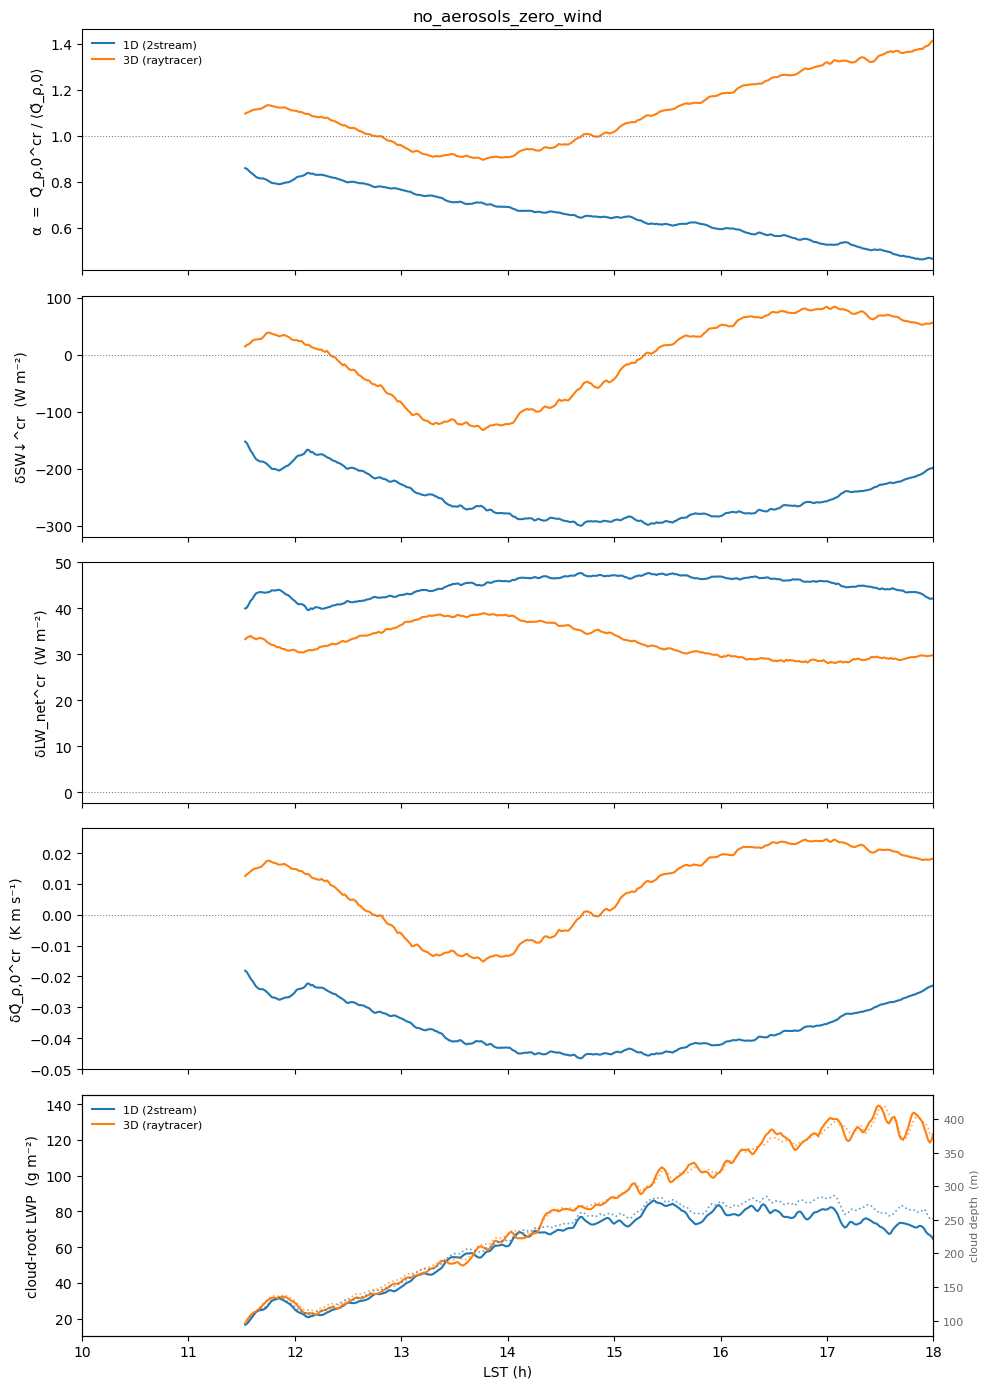


Time-mean α (LST 11.5–17, cf > 1%):
  1D (2stream): α = 0.686 ± 0.089
  3D (raytracer): α = 1.061 ± 0.118

  α_3D / α_1D = 1.546  (≈ growth-rate ratio)


In [5]:
# ── Figure: α(t) and supporting context ──────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

# Restrict to cloudy period
_e0 = ens[CASES[0]['key']]
cloudy = (_e0['cf'] > 0.01) & (_e0['lst'] >= 10) & (_e0['lst'] <= 18)

for case in CASES:
    e = ens[case['key']]
    lst = e['lst']
    c = RT_STYLE[case['rt']]['color']
    lbl = RT_LABEL[case['rt']]

    # Panel 0: α
    axes[0].plot(lst[cloudy], e['alpha'][cloudy], color=c, lw=1.5, label=lbl)

    # Panel 1: δSW↓^cr
    axes[1].plot(lst[cloudy], e['dsw_dn'][cloudy], color=c, lw=1.5, label=lbl)

    # Panel 2: δLW_net^cr
    axes[2].plot(lst[cloudy], e['dlw_net'][cloudy], color=c, lw=1.5, label=lbl)

    # Panel 3: δQ̃_ρ^cr
    axes[3].plot(lst[cloudy], e['dQ_rho'][cloudy], color=c, lw=1.5, label=lbl)

    # Panel 4: cloud-root LWP (left axis) and cloud depth (right axis)
    axes[4].plot(lst[cloudy], e['lwp_cr'][cloudy], color=c, lw=1.5, label=lbl)

axes[0].axhline(1, color='0.5', ls=':', lw=0.8)
axes[0].set_ylabel('α  =  Q̃_ρ,0^cr / ⟨Q̃_ρ,0⟩')
axes[0].legend(fontsize=8, frameon=False)
axes[0].set_title(f'{EXPT_KEY}')

axes[1].axhline(0, color='0.5', ls=':', lw=0.8)
axes[1].set_ylabel('δSW↓^cr  (W m⁻²)')

axes[2].axhline(0, color='0.5', ls=':', lw=0.8)
axes[2].set_ylabel('δLW_net^cr  (W m⁻²)')

axes[3].axhline(0, color='0.5', ls=':', lw=0.8)
axes[3].set_ylabel('δQ̃_ρ,0^cr  (K m s⁻¹)')

axes[4].set_ylabel('cloud-root LWP  (g m⁻²)')
axes[4].legend(fontsize=8, frameon=False, loc='upper left')

# Overlay cloud depth on right axis
ax4r = axes[4].twinx()
for case in CASES:
    e = ens[case['key']]
    ax4r.plot(e['lst'][cloudy], e['depth_cr'][cloudy],
              color=RT_STYLE[case['rt']]['color'], lw=1.2, ls=':', alpha=0.7)
ax4r.set_ylabel('cloud depth  (m)', fontsize=8, color='0.4')
ax4r.tick_params(labelcolor='0.4', labelsize=8)

axes[4].set_xlabel('LST (h)')
axes[4].set_xlim(10, 18)

plt.tight_layout()
if SAVE_PDF:
    plt.savefig('alpha_diurnal.pdf', bbox_inches='tight')
plt.show()

# ── Time-mean α over cloudy period (LST 11.5–17) ─────────────────────────────
win = lst_window_mask(_e0['t_sec']) & (_e0['cf'] > 0.01)
print('\nTime-mean α (LST 11.5–17, cf > 1%):')
for case in CASES:
    e = ens[case['key']]
    a = e['alpha'][win]
    print(f"  {RT_LABEL[case['rt']]}: α = {np.nanmean(a):.3f} ± {np.nanstd(a):.3f}")

e1, e3 = ens['1D'], ens['3D']
ratio = np.nanmean(e3['alpha'][win]) / np.nanmean(e1['alpha'][win])
print(f'\n  α_3D / α_1D = {ratio:.3f}  (≈ growth-rate ratio)')

## Task 1: β — partitioning coefficient

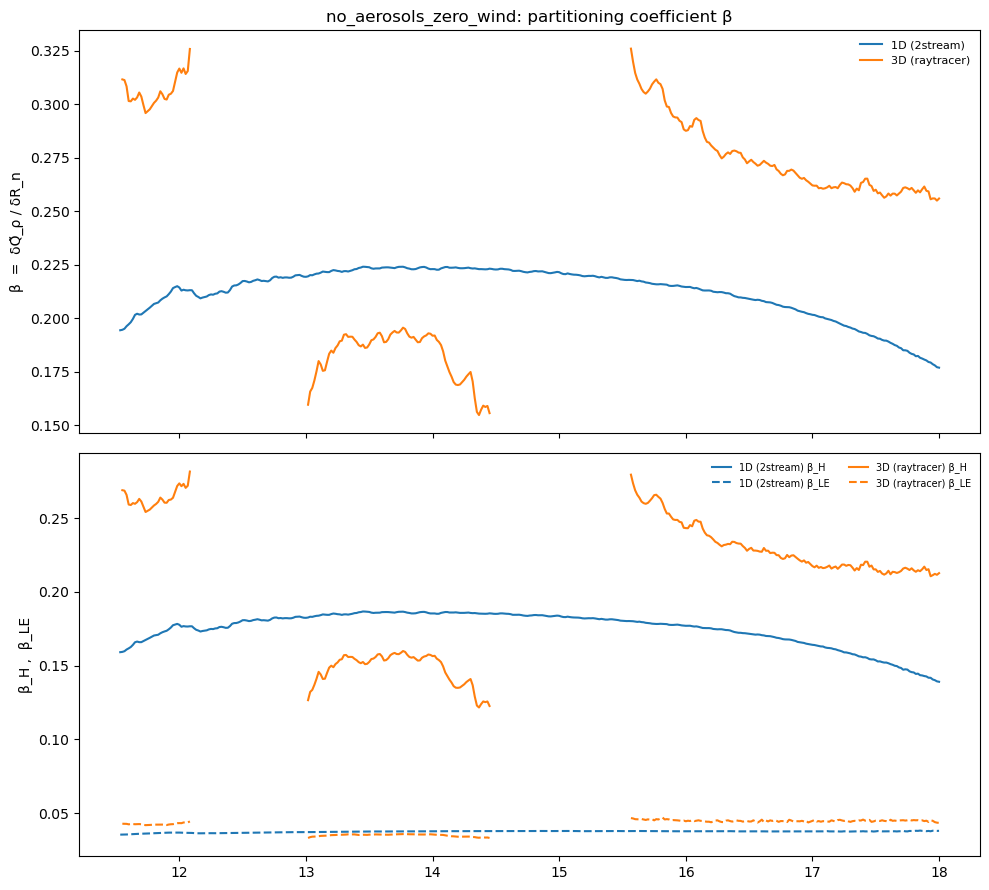


Time-mean β (LST 11.5–17, cf > 1%):
  1D (2stream):
    β = 0.2165,  β_H = 0.1792,  β_LE = 0.0373
    ⟨δLW_net^cr⟩ = 45.0 W m⁻²  vs  ⟨δSW↓^cr⟩ = -254.5 W m⁻²
  3D (raytracer):
    β = 0.2449,  β_H = 0.2046,  β_LE = 0.0403
    ⟨δLW_net^cr⟩ = 33.4 W m⁻²  vs  ⟨δSW↓^cr⟩ = -22.2 W m⁻²


In [6]:
# ── Figure: β and its components ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

for case in CASES:
    e = ens[case['key']]
    lst = e['lst']
    c = RT_STYLE[case['rt']]['color']
    lbl = RT_LABEL[case['rt']]

    axes[0].plot(lst[cloudy], e['beta'][cloudy],    color=c, lw=1.5, label=lbl)
    axes[1].plot(lst[cloudy], e['beta_H'][cloudy],  color=c, lw=1.5, label=f'{lbl} β_H')
    axes[1].plot(lst[cloudy], e['beta_LE'][cloudy], color=c, lw=1.5, ls='--', label=f'{lbl} β_LE')

axes[0].set_ylabel('β  =  δQ̃_ρ / δR_n')
axes[0].legend(fontsize=8, frameon=False)
axes[0].set_title(f'{EXPT_KEY}: partitioning coefficient β')

axes[1].set_ylabel('β_H ,  β_LE')
axes[1].legend(fontsize=7, frameon=False, ncol=2)


plt.tight_layout()
if SAVE_PDF:
    plt.savefig('beta_diurnal.pdf', bbox_inches='tight')
plt.show()

# ── Time-mean β ──────────────────────────────────────────────────────────────
print('\nTime-mean β (LST 11.5–17, cf > 1%):')
for case in CASES:
    e = ens[case['key']]
    b  = e['beta'][win]
    bH = e['beta_H'][win]
    bL = e['beta_LE'][win]
    dlw = e['dlw_net'][win]
    dsw = e['dsw_dn'][win]
    print(f"  {RT_LABEL[case['rt']]}:")
    print(f'    β = {np.nanmean(b):.4f},  β_H = {np.nanmean(bH):.4f},  β_LE = {np.nanmean(bL):.4f}')
    print(f'    ⟨δLW_net^cr⟩ = {np.nanmean(dlw):.1f} W m⁻²  vs  ⟨δSW↓^cr⟩ = {np.nanmean(dsw):.1f} W m⁻²')

## Subtask 2: Verify linear Q̃_ρ(z) profiles

Plot the equivalent buoyancy flux profile $\tilde Q_\rho(z) = w'\theta_l'(z) + \epsilon_v \Theta\, w'q_t'(z)$ from 3D dumps. Two versions: domain-mean and cloud-conditional. Linear fits from surface to $z_a$ (cloud top) to test the Stevens (2007) quasi-steady assumption.

In [7]:
# ── Load 3D dumps and stats for Q̃_ρ(z) profiles ─────────────────────────────
import xarray as xr
from cass_analysis import load_sfc_xy as _load_xy

# Target LST hours for profile snapshots (use 3D dump times closest to these)
TARGET_LST = [13.5, 14.5, 15.5]
# Corresponding sim seconds: LST - 5.5 = sim hours → x3600
TARGET_SIM_SEC = [(lst_h - LST_OFFSET) * 3600 for lst_h in TARGET_LST]

# z range for plotting (surface to ~500 m above cloud top)
Z_MAX_PLOT = 4000.0  # m




def compute_Qrho_profiles(run_dir):
    """Compute domain-mean and cloud-conditional Q_rho(z) from 3D dumps.

    Returns dict keyed by sim_time (seconds) with profile arrays.
    """
    run_dir = Path(run_dir)
    ds_3d = load_3d_nc(run_dir, variables=['thl', 'qt', 'ql', 'w', 'b'])
    stats = load_stats(run_dir)

    # xy LWP for cloud mask (nearest time matching)
    lwp_xy, lwp_tsec = _load_xy(run_dir, 'qlqi_path')

    z = ds_3d.z.values
    t_3d = ds_3d.time.values  # local datetime64
    # Get raw seconds from file
    ds_3d_raw = xr.open_mfdataset(
        [str(run_dir / f'{v}.nc') for v in ['thl', 'qt', 'ql', 'w', 'b']],
        decode_times=False, chunks={'time': 1, 'z': -1})
    t_3d_sec = ds_3d_raw.time.values
    ds_3d_raw.close()

    results = {}
    for t_target in TARGET_SIM_SEC:
        tidx = int(np.argmin(np.abs(t_3d_sec - t_target)))
        actual_sec = t_3d_sec[tidx]
        actual_lst = sim_time_to_lst(np.array([actual_sec]))[0]

        ds_t = ds_3d.isel(time=tidx).load()

        # Cloud mask from nearest xy timestep
        lwp_tidx = int(np.argmin(np.abs(lwp_tsec - actual_sec)))
        cmask = lwp_xy[lwp_tidx] > LWP_THRESH  # (ny, nx) bool

        # Cloud base from stats ql_frac; z_a from cloud fraction threshold
        st_tidx = int(np.argmin(np.abs(stats['t_sec'].values - actual_sec)))
        ql_frac = stats['ql_frac'].values[st_tidx]
        eta = compute_z_sl(stats, time_idx=st_tidx)  # cloud base (lowest ql_frac > 0)
        z_a = cloud_top_za(stats['z'].values, ql_frac, frac_of_peak=0.10)

        # Resolved fluxes: w' * thl', w' * qt'
        w_prime = ds_t['w_prime'].values    # (nz, ny, nx)
        thl_prime = ds_t['thl_prime'].values
        qt_prime = (ds_t['qt'] - ds_t['qt'].mean(['x', 'y'])).values

        flux_thl = w_prime * thl_prime     # w'thl' (nz, ny, nx)
        flux_qt  = w_prime * qt_prime      # w'qt'  (nz, ny, nx)

        # Q_rho(z) = w'thl'(z) + eps_v * Theta * w'qt'(z)
        Qrho_3d = flux_thl + eps_v * THETA_REF * flux_qt   # (nz, ny, nx)

        # Domain-mean profile
        Qrho_dm = np.nanmean(Qrho_3d, axis=(1, 2))
        thl_flux_dm = np.nanmean(flux_thl, axis=(1, 2))
        qt_flux_dm  = np.nanmean(flux_qt, axis=(1, 2))

        # Cloud-conditional profile
        mask_2d = cmask[np.newaxis, :, :]   # broadcast over z
        nc = int(cmask.sum())

        if nc > 0:
            Qrho_cr = np.nanmean(np.where(mask_2d, Qrho_3d, np.nan), axis=(1, 2))
            thl_flux_cr = np.nanmean(np.where(mask_2d, flux_thl, np.nan), axis=(1, 2))
            qt_flux_cr  = np.nanmean(np.where(mask_2d, flux_qt, np.nan), axis=(1, 2))
        else:
            Qrho_cr = np.full_like(z, np.nan)
            thl_flux_cr = np.full_like(z, np.nan)
            qt_flux_cr  = np.full_like(z, np.nan)

        results[actual_sec] = dict(
            z=z, lst=actual_lst, t_sec=actual_sec,
            Qrho_dm=Qrho_dm, Qrho_cr=Qrho_cr,
            thl_flux_dm=thl_flux_dm, thl_flux_cr=thl_flux_cr,
            qt_flux_dm=qt_flux_dm, qt_flux_cr=qt_flux_cr,
            z_sl=eta, z_a=z_a, eta=eta,
            n_cloud=nc, n_total=cmask.size,
        )
        del ds_t

    ds_3d.close()
    return results


# ── Load with caching ────────────────────────────────────────────────────────
_profile_cache = CASS_ROOT / 'analysis' / 'Qrho_profile_cache_v4.pkl'

if _profile_cache.exists():
    with open(_profile_cache, 'rb') as f:
        profile_data = _pkl.load(f)
    print(f'Loaded profiles from {_profile_cache}')
else:
    profile_data = {}
    for case in CASES:
        print(f"\n{RT_LABEL[case['rt']]}:")
        case_results = []
        for rd in rs.dirs[case['rt']]:
            if not rd.exists():
                print(f'  SKIP {rd.name}')
                continue
            print(f'  {rd.name} ...', end=' ', flush=True)
            case_results.append(compute_Qrho_profiles(rd))
            print('done')
        profile_data[case['key']] = case_results

    with open(_profile_cache, 'wb') as f:
        _pkl.dump(profile_data, f)
    print(f'\nCached to {_profile_cache}')

Loaded profiles from /pscratch/sd/m/mpowell/CASS_LES/analysis/Qrho_profile_cache_v4.pkl


In [8]:
# ── Ensemble-average profiles across reps ─────────────────────────────────────
def ensemble_profiles(case_reps):
    """Average profile dicts across reps for each target time."""
    # Get the set of sim times (should be identical across reps)
    all_times = sorted(case_reps[0].keys())
    out = {}
    for tsec in all_times:
        ref = case_reps[0][tsec]
        arrays = ['Qrho_dm', 'Qrho_cr', 'thl_flux_dm', 'thl_flux_cr',
                  'qt_flux_dm', 'qt_flux_cr']
        scalars = ['z_sl', 'z_a', 'eta', 'n_cloud', 'n_total']

        d = dict(z=ref['z'], lst=ref['lst'], t_sec=ref['t_sec'])
        for k in arrays:
            stack = np.stack([r[tsec][k] for r in case_reps], axis=0)
            d[k]          = np.nanmean(stack, axis=0)
            d[k + '_std'] = np.nanstd(stack, axis=0)
        for k in scalars:
            d[k] = np.mean([r[tsec][k] for r in case_reps])
        out[tsec] = d
    return out

prof_ens = {case['key']: ensemble_profiles(profile_data[case['key']]) for case in CASES}

# Report available times
for case in CASES:
    print(f"{RT_LABEL[case['rt']]}:")
    for tsec, d in sorted(prof_ens[case['key']].items()):
        print(f'  t={tsec:.0f}s  LST={d["lst"]:.1f}h  η={d["eta"]:.0f}m  z_a={d["z_a"]:.0f}m  '
              f'cf={d["n_cloud"]/d["n_total"]:.3f}')

1D (2stream):
  t=28800s  LST=13.5h  η=1288m  z_a=1875m  cf=0.157
  t=32400s  LST=14.5h  η=1362m  z_a=2138m  cf=0.162
  t=36000s  LST=15.5h  η=1438m  z_a=2381m  cf=0.155
3D (raytracer):
  t=28800s  LST=13.5h  η=1281m  z_a=1875m  cf=0.157
  t=32400s  LST=14.5h  η=1362m  z_a=2219m  cf=0.172
  t=36000s  LST=15.5h  η=1438m  z_a=2525m  cf=0.163


/tmp/ipykernel_1179169/2152604499.py:16: RuntimeWarning: Mean of empty slice
  d[k]          = np.nanmean(stack, axis=0)


Domain-mean linear fits (z ∈ [200 m, z_a]):
  LST               RT   intercept         slope      R²


NameError: name 'fit_linear' is not defined

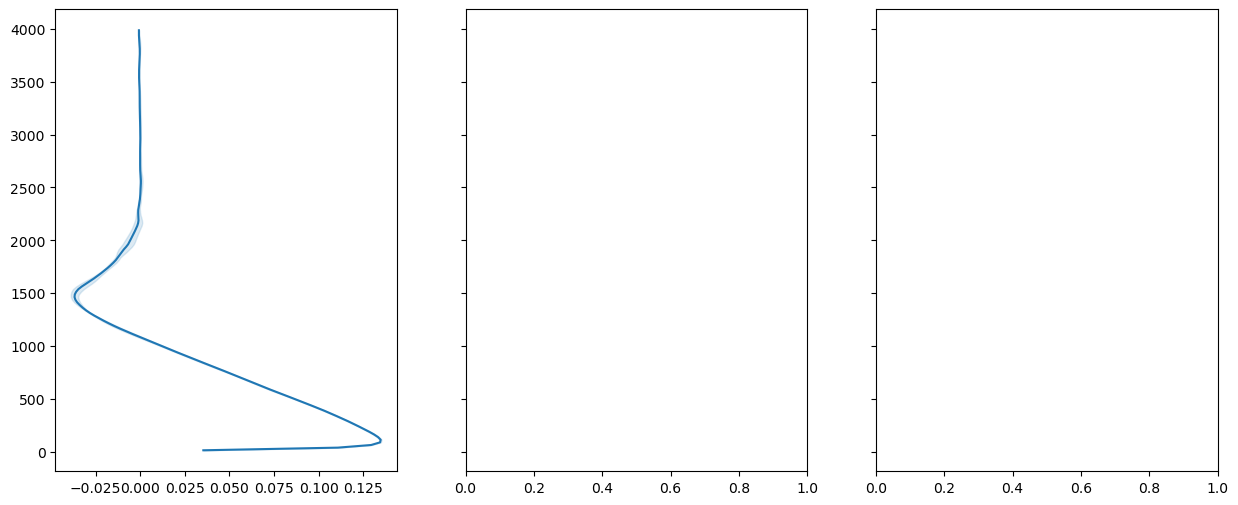

In [9]:

# ── Figure 1: Domain-mean Q̃_ρ(z) at representative times ────────────────────
time_keys = sorted(prof_ens[CASES[0]['key']].keys())
ncols = len(time_keys)
fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 6), sharey=True)
if ncols == 1:
    axes = [axes]


for ti, tsec in enumerate(time_keys):
    ax = axes[ti]
    for case in CASES:
        d = prof_ens[case['key']][tsec]
        z, Qrho = d['z'], d['Qrho_dm']
        z_a, eta = d['z_a'], d['eta']
        c, lbl = RT_STYLE[case['rt']]['color'], RT_LABEL[case['rt']]

        # Plot profile
        zplot = z[z <= Z_MAX_PLOT]
        ax.plot(Qrho[z <= Z_MAX_PLOT], zplot, color=c, lw=1.5, label=lbl)

        # Shading: ±1 std
        std = d['Qrho_dm_std']
        ax.fill_betweenx(zplot, (Qrho - std)[z <= Z_MAX_PLOT],
                         (Qrho + std)[z <= Z_MAX_PLOT], color=c, alpha=0.15)


    # Cloud base / top markers
    d0 = prof_ens[CASES[0]['key']][tsec]
    ax.axhline(d0['eta'], color='0.5', ls=':', lw=0.8, label='η (cloud base)')
    ax.axhline(d0['z_a'], color='0.5', ls='--', lw=0.8, label='z_a (cloud top)')
    ax.axhline(0, color='0.3', lw=0.5)
    ax.axvline(0, color='0.3', lw=0.5)

    ax.set_xlabel("Q̃_ρ  (K m s⁻¹)")
    ax.set_title(f'LST ≈ {d0["lst"]:.1f} h')
    if ti == 0:
        ax.set_ylabel('z  (m)')
        ax.legend(fontsize=7, frameon=False, loc='upper right')

fig.suptitle(f'{EXPT_KEY}: domain-mean Q̃_ρ(z)', fontsize=12, y=1.01)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig('Qrho_domain_mean.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# h(t) = mean cloud top height over cloudy columns (qlqi_top)
_ct_cache = CASS_ROOT / 'analysis' / 'ct_mean_cache.pkl'

if _ct_cache.exists():
    with open(_ct_cache, 'rb') as f:
        _ct_data = _pkl.load(f)
    print(f'Loaded from {_ct_cache}')
else:
    _ct_data = {}
    for case in CASES:
        print(f"{RT_LABEL[case['rt']]}:", end=" ", flush=True)
        reps = []
        for rd in rs.dirs[case['rt']]:
            if not rd.exists():
                continue
            ct_xy, t_sec = load_sfc_xy(rd, 'qlqi_top')
            nt = len(t_sec)
            ct_mean = np.full(nt, np.nan)
            for ti in range(nt):
                cloudy = ct_xy[ti] > 0
                if cloudy.sum() > 10:
                    ct_mean[ti] = np.nanmean(ct_xy[ti][cloudy])
            reps.append(dict(t_sec=t_sec, ct_mean=ct_mean))
        _ct_data[case['key']] = reps
        print('done')
    with open(_ct_cache, 'wb') as f:
        _pkl.dump(_ct_data, f)
    print(f'Cached to {_ct_cache}')

# Ensemble-average, interpolated to alpha (xy) time grid
_t_a = ens['1D']['t_sec']
_lst = ens['1D']['lst']

h_a = {}
for case in CASES:
    reps = _ct_data[case['key']]
    stack = np.stack([np.interp(_t_a, r['t_sec'], r['ct_mean']) for r in reps])
    h_a[case['key']] = np.nanmean(stack, axis=0)

# alpha ratio time series
alpha_ratio = ens['3D']['alpha'] / np.where(
    np.abs(ens['1D']['alpha']) > 1e-6, ens['1D']['alpha'], np.nan)

# Base mask: cloudy period, finite alpha
win = (lst_window_mask(ens['1D']['t_sec'])
       & (ens['1D']['cf'] > 0.01) & (ens['3D']['cf'] > 0.01)
       & np.isfinite(alpha_ratio))


SyntaxError: unterminated string literal (detected at line 11) (4035310957.py, line 11)

In [10]:
BIN_MIN = 30
bin_edges = np.arange(_lst[win].min(), _lst[win].max() + BIN_MIN/60, BIN_MIN/60)

alpha_ratio_binned = []
dhdt_ratio_binned = []
lst_binned = []

for i in range(len(bin_edges) - 1):
    in_bin = win & (_lst >= bin_edges[i]) & (_lst < bin_edges[i+1])
    if in_bin.sum() < 5:
        continue

    # alpha ratio: bin-mean
    alpha_ratio_binned.append(np.nanmean(alpha_ratio[in_bin]))
    lst_binned.append(0.5 * (bin_edges[i] + bin_edges[i+1]))

    # dh/dt: per-bin linear regression of h(t)
    t_bin = _t_a[in_bin]
    sl_3d = linregress(t_bin, h_a['3D'][in_bin]).slope
    sl_1d = linregress(t_bin, h_a['1D'][in_bin]).slope

    if sl_1d > 1e-5 and sl_3d > 1e-5:
        dhdt_ratio_binned.append(sl_3d / sl_1d)
    else:
        dhdt_ratio_binned.append(np.nan)

alpha_ratio_binned = np.array(alpha_ratio_binned)
dhdt_ratio_binned = np.array(dhdt_ratio_binned)
lst_binned = np.array(lst_binned)

# Drop NaN bins
valid = np.isfinite(dhdt_ratio_binned) & np.isfinite(alpha_ratio_binned)
alpha_ratio_binned = alpha_ratio_binned[valid]
dhdt_ratio_binned = dhdt_ratio_binned[valid]
lst_binned = lst_binned[valid]

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(alpha_ratio_binned, dhdt_ratio_binned,
                c=lst_binned, cmap='viridis', s=60, edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='LST (h)', pad=0.1, shrink=0.5)

lo = min(np.nanmin(alpha_ratio_binned), np.nanmin(dhdt_ratio_binned)) * 0.9
hi = max(np.nanmax(alpha_ratio_binned), np.nanmax(dhdt_ratio_binned)) * 1.1
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4, label='1:1 (no damping)')

slope, intercept, _, _, _ = linregress(alpha_ratio_binned, dhdt_ratio_binned)
x_fit = np.linspace(lo, hi, 50)
ax.plot(x_fit, slope * x_fit + intercept, 'r-', lw=1.2, alpha=0.7,
        label=f'best fit: slope = {slope:.2f}')

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel(r'$\alpha_{\rm 3D}\;/\;\alpha_{\rm 1D}$')
ax.set_ylabel(r'$(dh/dt)_{\rm 3D}\;/\;(dh/dt)_{\rm 1D}$')
ax.set_title(f'{EXPT_KEY}: growth-rate ratio vs coupling ratio\n'
             f'(dh/dt via per-bin regression, {BIN_MIN}-min bins)')
ax.legend(fontsize=8, frameon=False, loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
if SAVE_PDF:
    plt.savefig('dhdt_vs_alpha_ratio_binned.pdf', bbox_inches='tight')
plt.show()

if len(alpha_ratio_binned) > 3:
    r, p = pearsonr(alpha_ratio_binned, dhdt_ratio_binned)
    print(f'Binned: Pearson r = {r:.3f}, p = {p:.2e}, N = {len(alpha_ratio_binned)}')
    print(f'Best-fit slope = {slope:.3f}')


NameError: name '_lst' is not defined